In [1]:
from run_simulation import run_simulation, print_statistics
import simpy

# Run the simulation
num_permits = 6410
print("Running simulation with " + str(num_permits) + " permits...")
sim = run_simulation(
    num_permits=num_permits,
    random_seed=42,
    inter_arrival_time=0,
    sequential = "standard"
)

# Get and display statistics
stats = sim.get_statistics()
print_statistics(stats)

Running simulation with 6410 permits...

SIMULATION STATISTICS

Total Completed Permits: 6410
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 4630 (72.23%)
  CUSTOM_NON_LIKE               : 1148 (17.91%)
  PRE_APPROVED_LIKE             :   93 ( 1.45%)
  PRE_APPROVED_NON_LIKE         :   21 ( 0.33%)
  SELF_CERT_LIKE                :  425 ( 6.63%)
  SELF_CERT_NON_LIKE            :   93 ( 1.45%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     269.60 days
  Median:   257.81 days
  Std Dev:  116.65 days
  Min:       55.13 days
  Max:     1268.97 days

--------------------------------------------------------------------------------
PROCESSING TI

In [2]:
# Optional: Access individual permit data
print(f"\nFirst 5 completed permits:")
for permit in sim.completed_permits[:5]:
    total_time = permit.ready_for_construction - permit.created_at if permit.ready_for_construction else None
    print(f"  Permit {permit.permit_id} ({permit.segment.name}): "
          f"{total_time:.2f} days total, "
          f"{permit.public_works_rechecks} re-checks")



First 5 completed permits:
  Permit 149 (PRE_APPROVED_LIKE): 55.13 days total, 1 re-checks
  Permit 284 (SELF_CERT_LIKE): 60.33 days total, 1 re-checks
  Permit 241 (PRE_APPROVED_LIKE): 63.02 days total, 1 re-checks
  Permit 410 (CUSTOM_LIKE): 65.16 days total, 1 re-checks
  Permit 319 (PRE_APPROVED_LIKE): 69.08 days total, 0 re-checks


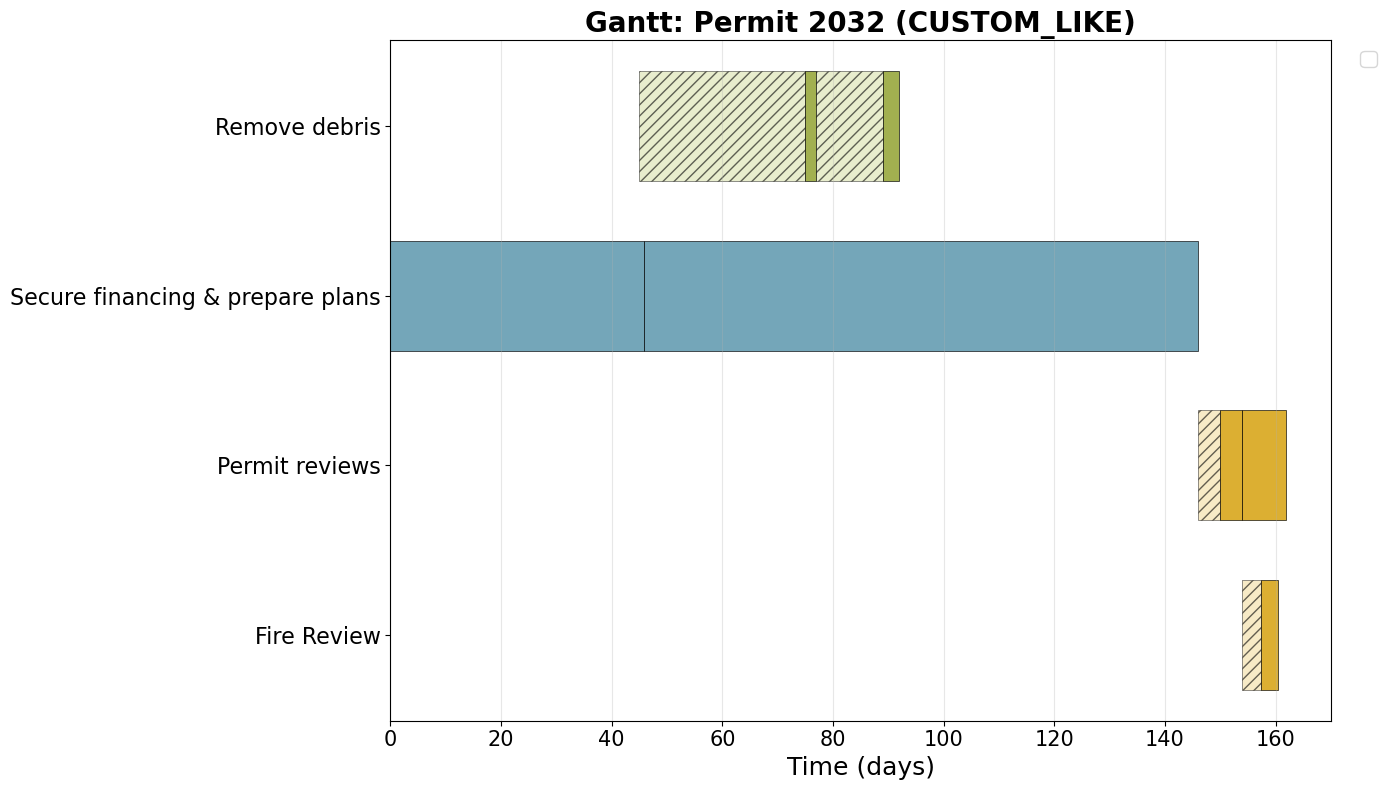

In [3]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_single_permit
import matplotlib.pyplot as plt

fig, ax = plot_gantt_single_permit(
    sim.completed_permits[1100],
    figsize=(14, 8), 
)
if fig:
    plt.show()

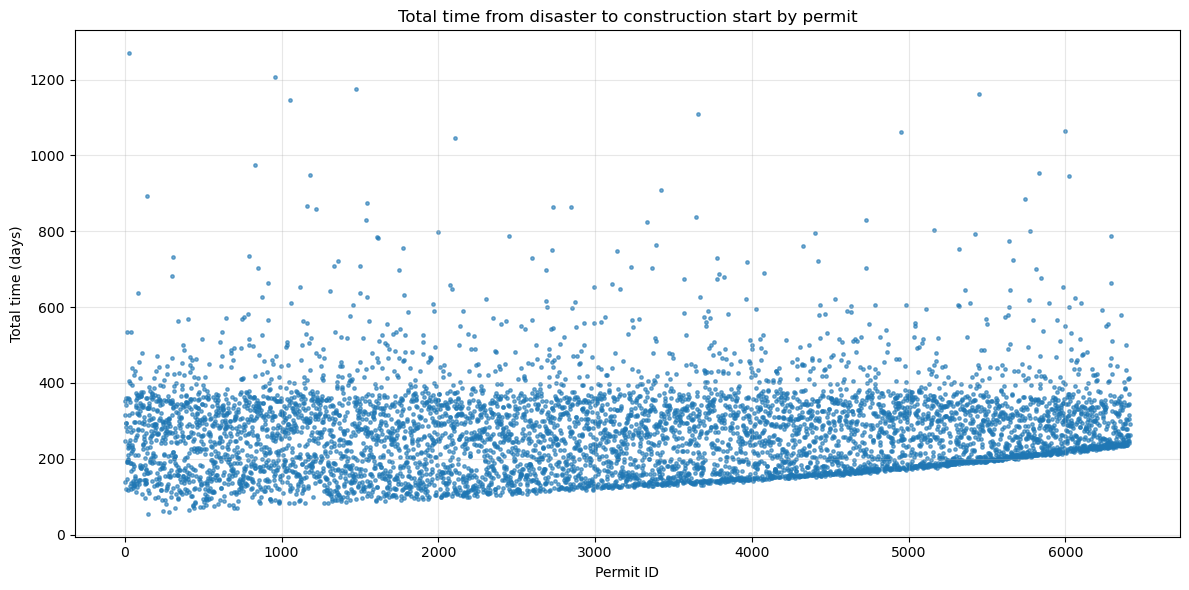

In [4]:
# Plot permit number (ID) vs total time to construction
import matplotlib.pyplot as plt

permit_ids = []
total_times = []

for p in sim.completed_permits:
    if p.ready_for_construction is not None and p.created_at is not None:
        permit_ids.append(p.permit_id)
        total_times.append(p.ready_for_construction - p.created_at)

plt.figure(figsize=(12, 6))
plt.scatter(permit_ids, total_times, s=6, alpha=0.6)
plt.xlabel("Permit ID")
plt.ylabel("Total time (days)")
plt.title("Total time from disaster to construction start by permit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Creating visualizations for 6410 permits...
  Creating stacked bar chart...
  Creating average time by stage chart...
  Creating time by segment chart...
  Creating time by segment chart (Like-for-like only)...
  Creating time by segment chart (Non-like-for-like only)...
  Creating total time by segment chart (box plot)...
  Creating waiting vs service by step chart...


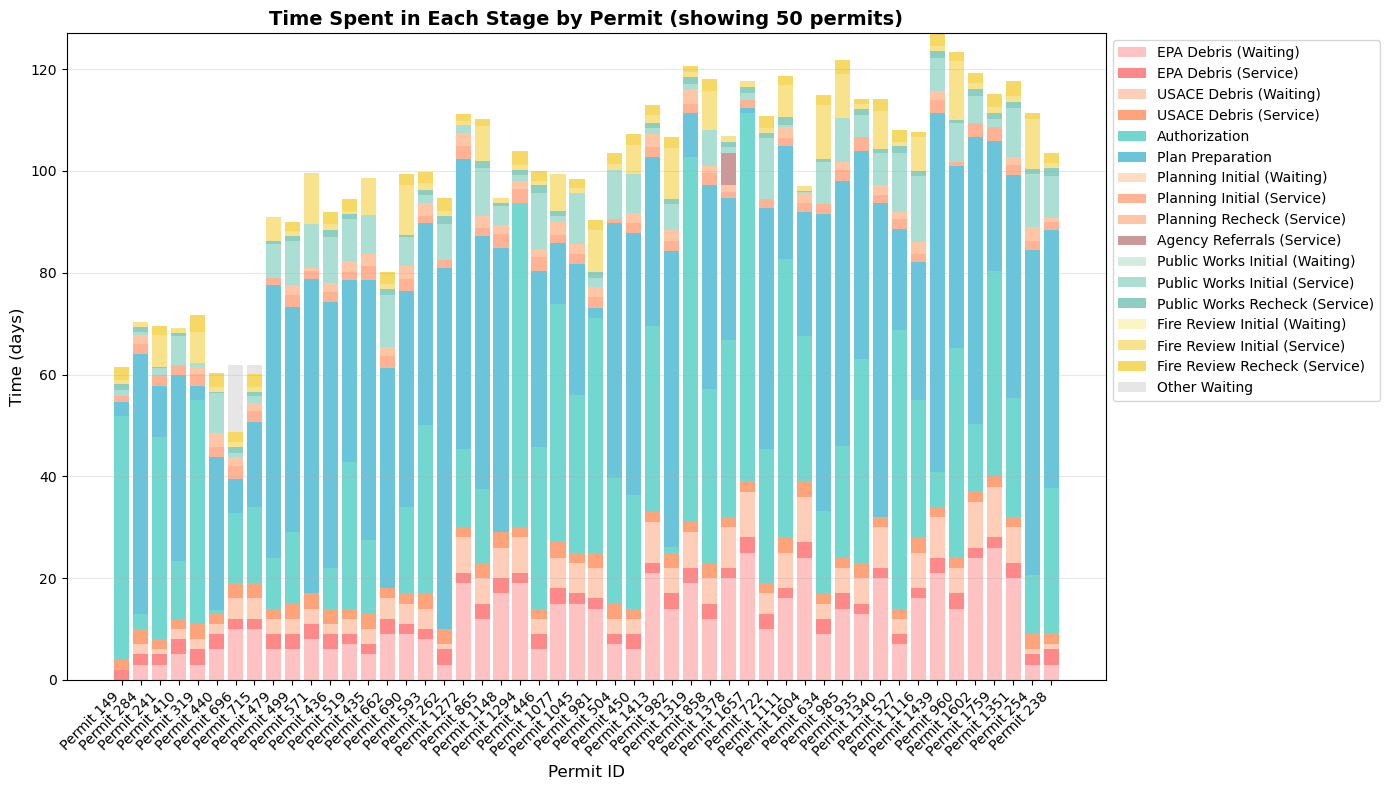

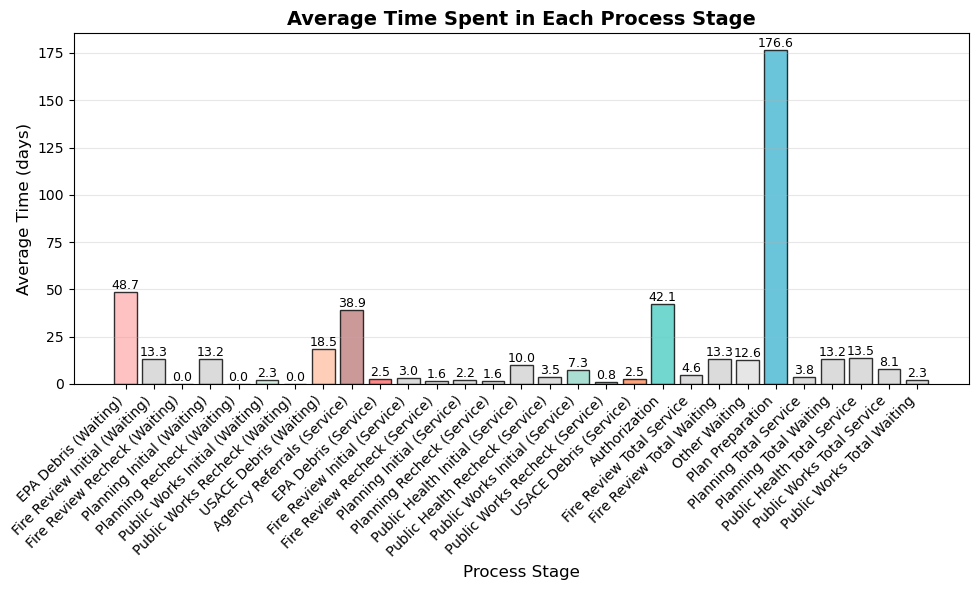

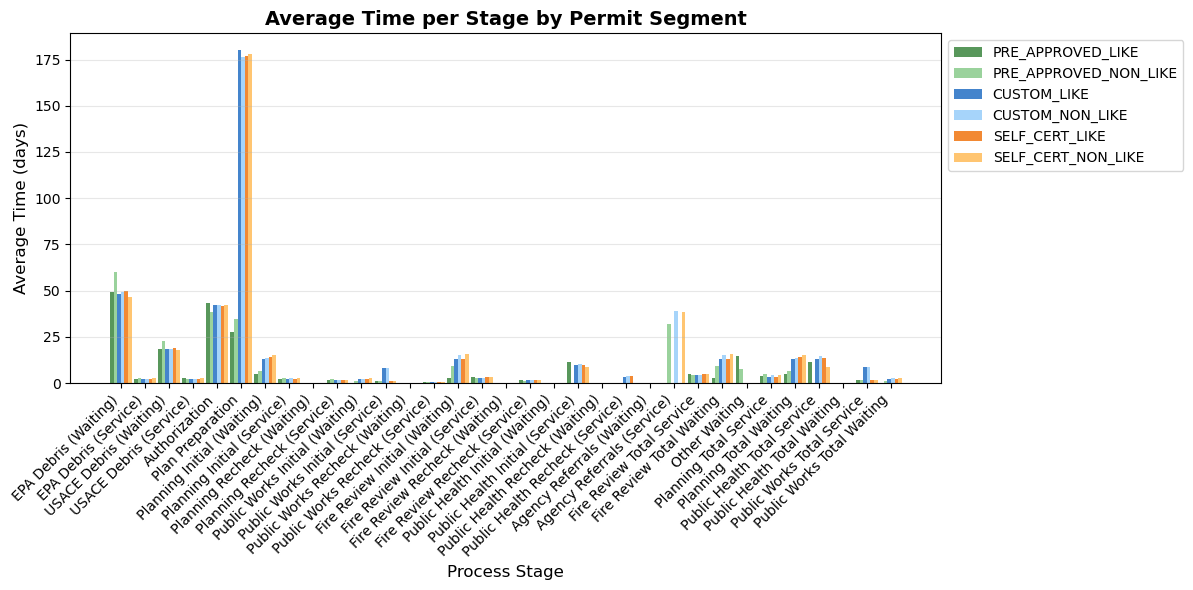

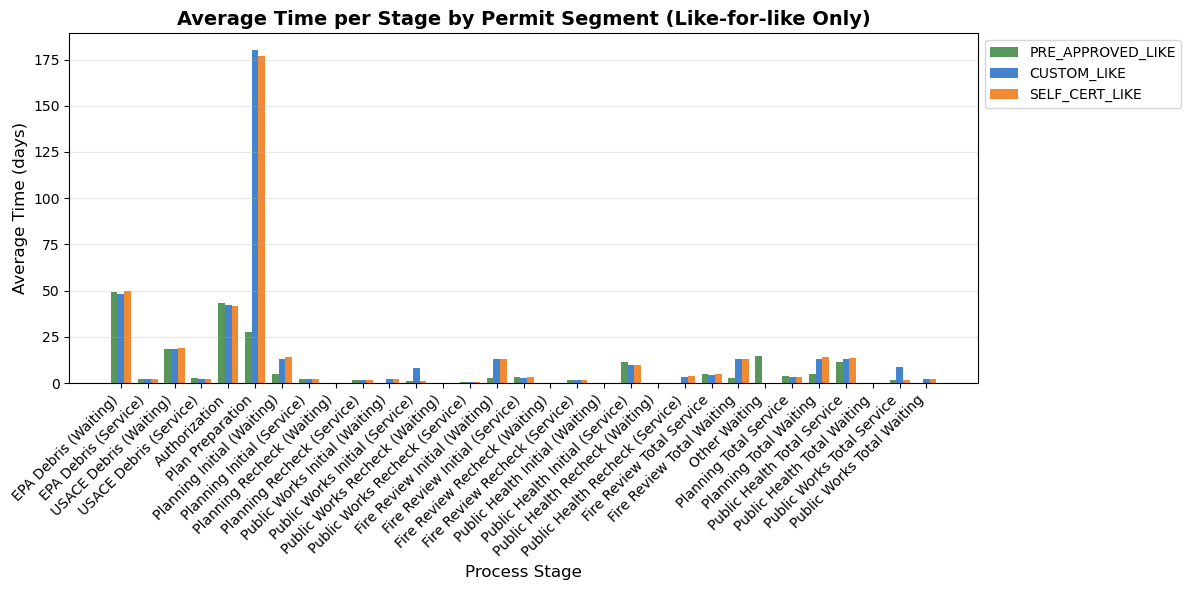

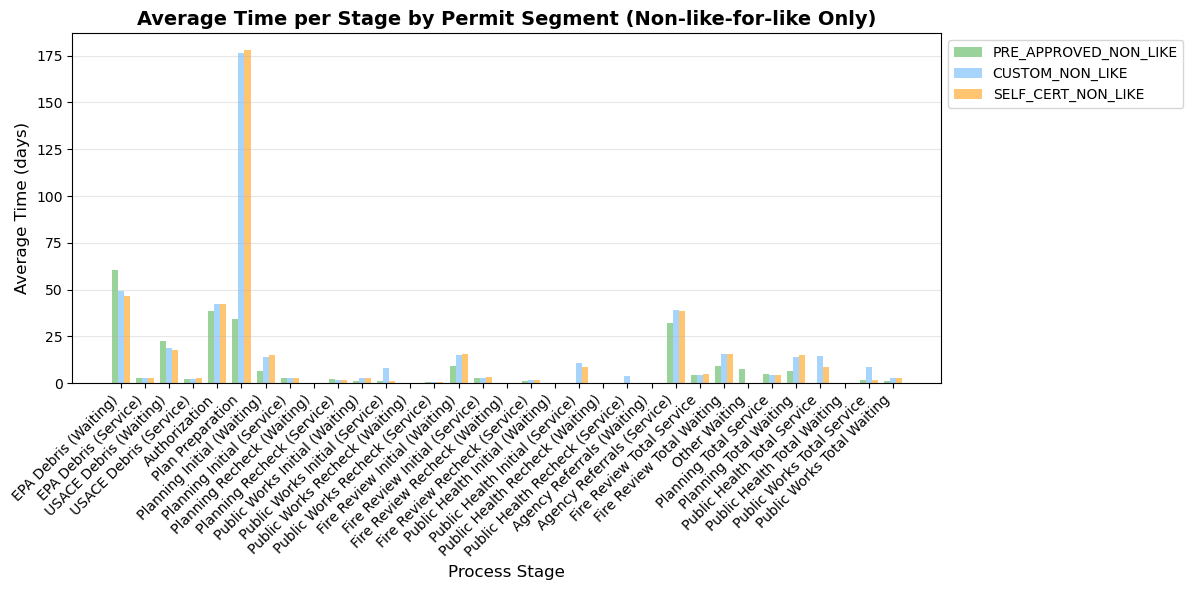

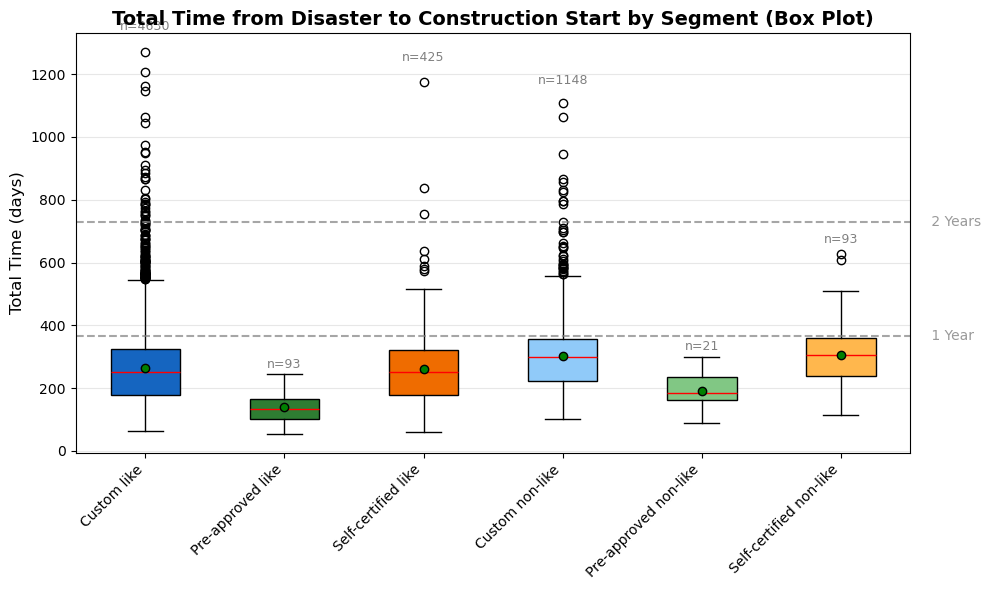

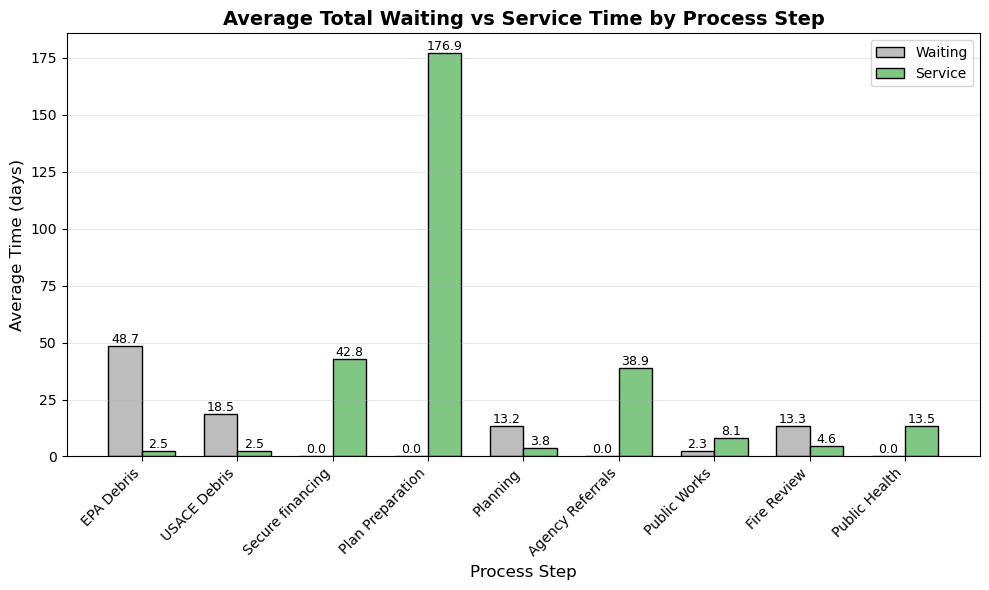

Visualizations complete!


In [5]:
# Visualize the time each permit spends in each stage
from visualize_permits import visualize_all, plot_stacked_bar_chart, plot_average_time_by_stage

# Create all visualizations
visualize_all(sim.completed_permits)

# Or create individual visualizations:
# plot_stacked_bar_chart(sim.completed_permits, max_permits=30)  # Stacked bar chart
# plot_gantt_chart(sim.completed_permits, max_permits=20)        # Gantt chart
# plot_average_time_by_stage(sim.completed_permits)              # Average time by stage


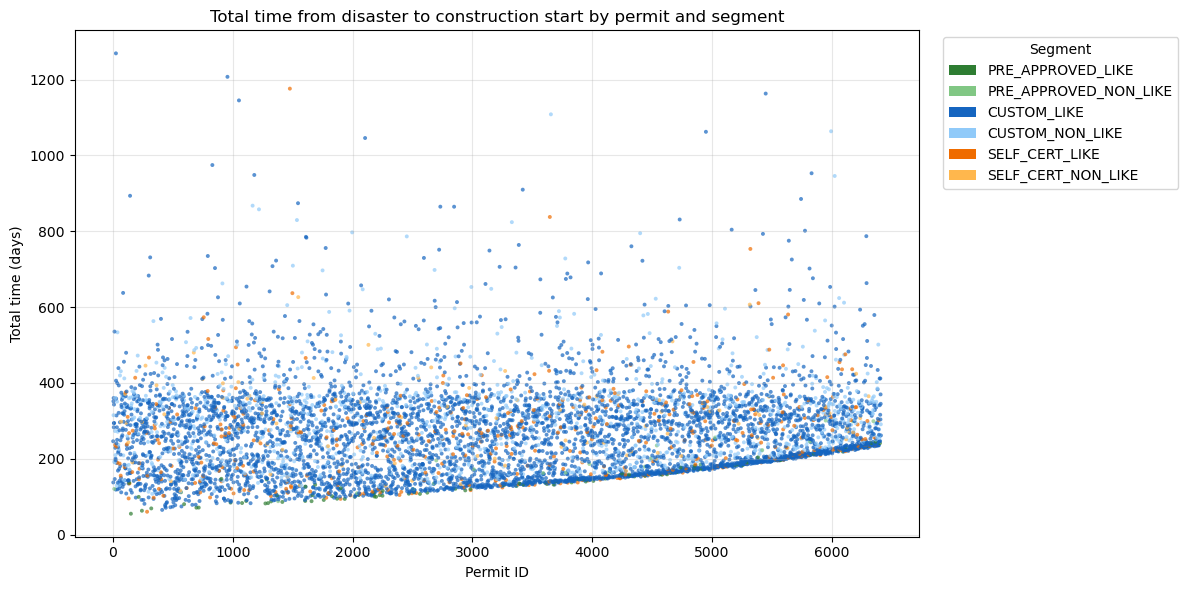

In [6]:
# Scatter plot: permit ID vs total time, colored by segment
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

permit_ids = []
total_times = []
segments = []

for p in sim.completed_permits:
    if p.ready_for_construction is None or p.created_at is None:
        continue
    permit_ids.append(p.permit_id)
    total_times.append(p.ready_for_construction - p.created_at)
    segments.append(p.segment)

# Define a color for each segment
from permit_simulation import Segment
segment_colors = {
    Segment.PRE_APPROVED_LIKE: "#2E7D32",      # green
    Segment.PRE_APPROVED_NON_LIKE: "#81C784",  # light green
    Segment.CUSTOM_LIKE: "#1565C0",            # blue
    Segment.CUSTOM_NON_LIKE: "#90CAF9",        # light blue
    Segment.SELF_CERT_LIKE: "#EF6C00",         # orange
    Segment.SELF_CERT_NON_LIKE: "#FFB74D",     # light orange,
}

colors = [segment_colors.get(seg, "#888888") for seg in segments]

plt.figure(figsize=(12, 6))
plt.scatter(permit_ids, total_times, c=colors, s=8, alpha=0.7, edgecolors="none")
plt.xlabel("Permit ID")
plt.ylabel("Total time (days)")
plt.title("Total time from disaster to construction start by permit and segment")
plt.grid(alpha=0.3)

# Legend
legend_patches = []
for seg, color in segment_colors.items():
    legend_patches.append(Patch(facecolor=color, edgecolor="none", label=seg.name))
plt.legend(handles=legend_patches, title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

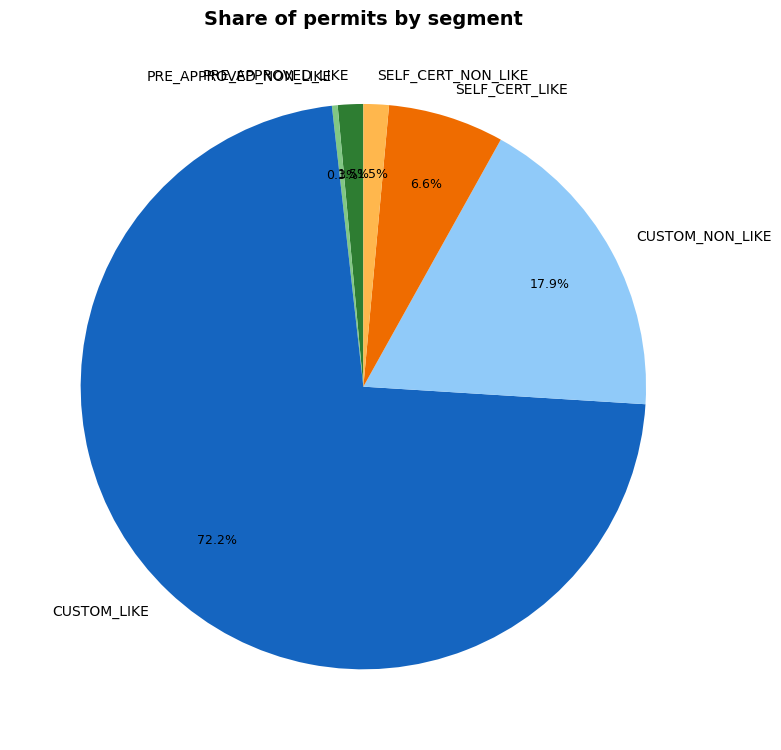

In [7]:
# Pie chart: share of permits in each segment
import matplotlib.pyplot as plt
from permit_simulation import Segment
from collections import Counter

counts = Counter(p.segment for p in sim.completed_permits)
segment_order = [
    Segment.PRE_APPROVED_LIKE,
    Segment.PRE_APPROVED_NON_LIKE,
    Segment.CUSTOM_LIKE,
    Segment.CUSTOM_NON_LIKE,
    Segment.SELF_CERT_LIKE,
    Segment.SELF_CERT_NON_LIKE,
]
labels = [seg.name for seg in segment_order]
sizes = [counts.get(seg, 0) for seg in segment_order]
colors = [
    "#2E7D32", "#81C784", "#1565C0", "#90CAF9", "#EF6C00", "#FFB74D",
]

# Only show segments that have at least one permit
non_zero = [(l, s, c) for l, s, c in zip(labels, sizes, colors) if s > 0]
if non_zero:
    labels, sizes, colors = zip(*non_zero)
    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.75,
    )
    for t in texts:
        t.set_fontsize(10)
    for t in autotexts:
        t.set_fontsize(9)
    ax.set_title("Share of permits by segment", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No completed permits to plot.")

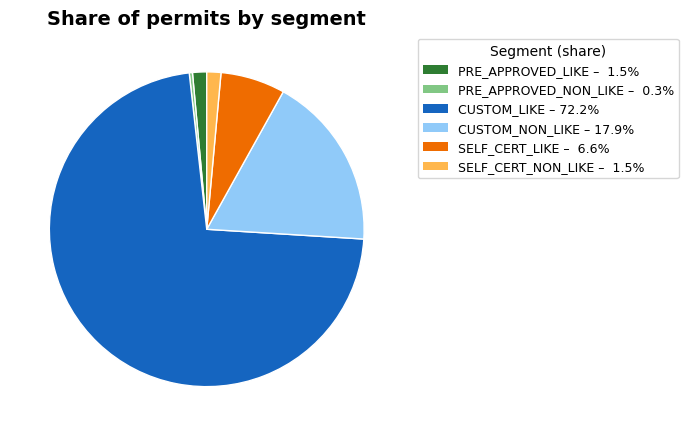

In [8]:
# Improved pie chart: share of permits in each segment (readable legend)
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import Counter
from permit_simulation import Segment

# Count permits per segment
counts = Counter(p.segment for p in sim.completed_permits)
segment_order = [
    Segment.PRE_APPROVED_LIKE,
    Segment.PRE_APPROVED_NON_LIKE,
    Segment.CUSTOM_LIKE,
    Segment.CUSTOM_NON_LIKE,
    Segment.SELF_CERT_LIKE,
    Segment.SELF_CERT_NON_LIKE,
]
labels = [seg.name for seg in segment_order]
sizes = [counts.get(seg, 0) for seg in segment_order]
colors = [
    "#2E7D32", "#81C784", "#1565C0", "#90CAF9", "#EF6C00", "#FFB74D",
]

# Only keep non-zero segments
non_zero = [(l, s, c) for l, s, c in zip(labels, sizes, colors) if s > 0]
if not non_zero:
    print("No completed permits to plot.")
else:
    labels, sizes, colors = zip(*non_zero)

    fig, ax = plt.subplots(figsize=(7, 7))
    wedges, _ = ax.pie(
        sizes,
        colors=colors,
        startangle=90,
        wedgeprops={"linewidth": 1, "edgecolor": "white"},
    )

    # Legend shows segment name and percentage
    total = sum(sizes)
    legend_labels = [f"{lbl} – {s/total*100:4.1f}%" for lbl, s in zip(labels, sizes)]
    legend_patches = [
        Patch(facecolor=c, edgecolor="none", label=lab)
        for c, lab in zip(colors, legend_labels)
    ]

    ax.legend(
        handles=legend_patches,
        title="Segment (share)",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        title_fontsize=10,
    )

    ax.set_title("Share of permits by segment", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

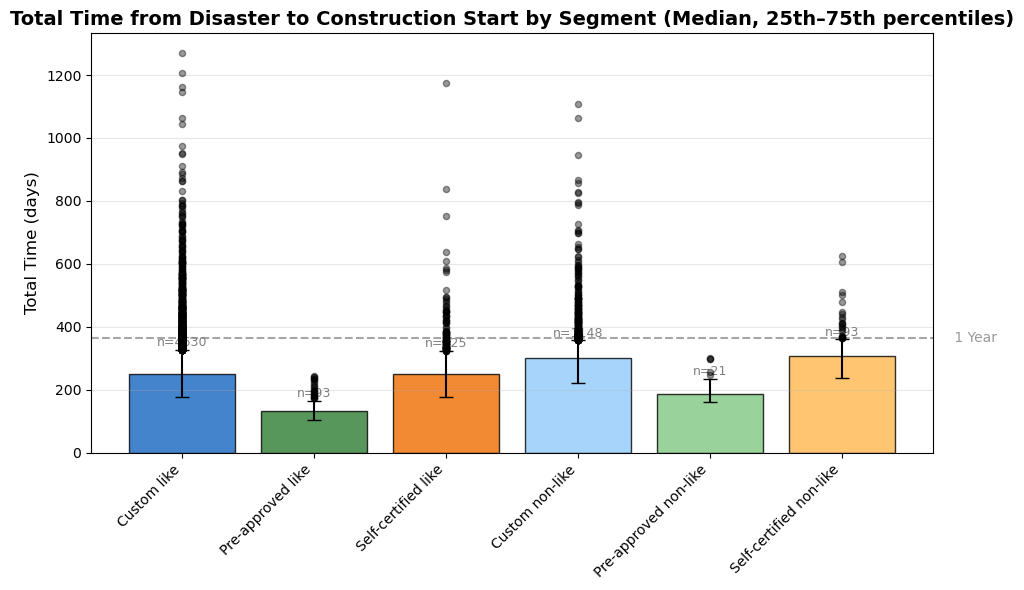

In [9]:
from visualize_permits import plot_total_time_by_segment_quartiles

fig, ax = plot_total_time_by_segment_quartiles(sim.completed_permits)
plt.show()